# Notebook 11: Multi-Layer SAE Analysis (Experiment A1)

**Purpose:** Train SAEs on three different GPT-2 layers (0, 6, 11) and
compare detection performance + evasion resistance across layers.

**Hypothesis:** Deeper layers encode more abstract, task-relevant features.
Layer 0 captures surface-level patterns. Layer 6 (middle) may have the
best balance of abstraction and specificity. Layer 11 (final) may
over-specialize on next-token prediction.

**Prerequisites:** Run notebook 10 first (expanded dataset + activations).

**Runtime:** Colab GPU (T4), ~30 minutes (3 SAE training runs).

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -r /content/drive/MyDrive/iris/requirements.txt -q

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/iris')

import json
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import StratifiedKFold

from src.utils.helpers import set_seed, get_device
set_seed(42)
device = get_device()

DRIVE_ROOT = Path('/content/drive/MyDrive/iris')

Using GPU: Tesla T4


In [3]:
# Load activations — use expanded if available, otherwise original
expanded_path = DRIVE_ROOT / 'checkpoints' / 'expanded_activations.npz'
original_path = DRIVE_ROOT / 'checkpoints' / 'j2_activations.npz'

if expanded_path.exists():
    print('Loading expanded activations...')
    act_data = np.load(str(expanded_path))
else:
    print('Loading original activations (expanded not found)...')
    act_data = np.load(str(original_path))

labels = act_data['labels']
print(f'Loaded {len(labels)} examples')
print(f'Label distribution: {dict(zip(*np.unique(labels, return_counts=True)))}')

Loading expanded activations...
Loaded 1000 examples
Label distribution: {0: 500, 1: 500}


## Step 1: Train SAEs on Layers 0, 6, and 11

We use the same architecture (8x expansion, lambda=1e-4) across all layers
so the only variable is *where* in the transformer we extract activations.

- **Layer 0:** Immediately after the embedding + positional encoding.
  Features here reflect surface-level token patterns.
- **Layer 6:** Middle of the network. Attention has had 6 layers to
  compose token-level signals into phrase/sentence-level representations.
- **Layer 11:** Final layer, just before the unembedding. Features here
  are optimized for next-token prediction and may be the most abstract.

In [4]:
from src.sae.training import train_sae

TARGET_LAYERS = [0, 6, 11]
EXPANSION_FACTOR = 8
SPARSITY_COEFF = 1e-4
EPOCHS = 20
D_INPUT = 768

trained_saes = {}

for layer in TARGET_LAYERS:
    print(f'\n{"="*60}')
    print(f'Training SAE on Layer {layer}')
    print(f'{"="*60}')

    layer_acts = torch.from_numpy(act_data[f'layer_{layer}'])

    result = train_sae(
        activations=layer_acts,
        d_input=D_INPUT,
        expansion_factor=EXPANSION_FACTOR,
        sparsity_coeff=SPARSITY_COEFF,
        epochs=EPOCHS,
        device=device,
        seed=42,
        checkpoint_dir=DRIVE_ROOT / 'checkpoints' / 'multi_layer',
    )

    trained_saes[layer] = result
    print(f'Layer {layer} final MSE: {result["final_metrics"]["final_mse_loss"]:.6f}')
    print(f'Layer {layer} final sparsity: {result["final_metrics"]["final_mean_sparsity"]:.3%}')


Training SAE on Layer 0
Dataset: 1000 activation vectors of dim 768
Input variance (mean per-element MSE from mean): 0.207457
J2 target — reconstruction MSE must be < 0.020746 (= 0.1 × input variance)

  Epoch 1/20  Batch 4/4  loss=2.562307  mse=2.561352  l1=0.954770  active=48.903%
[Epoch 1/20]  loss=5.922540  mse=5.921567  l1=0.973323  active=49.244%  J2-recon=FAIL  J2-sparse=FAIL

  Epoch 2/20  Batch 4/4  loss=2.669145  mse=2.668249  l1=0.896673  active=46.410%
[Epoch 2/20]  loss=3.089436  mse=3.088514  l1=0.921988  active=47.486%  J2-recon=FAIL  J2-sparse=FAIL

  Epoch 3/20  Batch 4/4  loss=1.297494  mse=1.296661  l1=0.832615  active=43.816%
[Epoch 3/20]  loss=1.639786  mse=1.638930  l1=0.855099  active=44.735%  J2-recon=FAIL  J2-sparse=FAIL

  Epoch 4/20  Batch 4/4  loss=1.112621  mse=1.111834  l1=0.786536  active=42.081%
[Epoch 4/20]  loss=1.097759  mse=1.096959  l1=0.799801  active=42.645%  J2-recon=FAIL  J2-sparse=FAIL

  Epoch 5/20  Batch 4/4  loss=0.770936  mse=0.770185  l1=

## Step 2: Compute Features & Sensitivity for Each Layer

In [5]:
from src.analysis.features import compute_feature_activations, compute_sensitivity_scores

layer_features = {}
layer_sensitivity = {}

for layer in TARGET_LAYERS:
    print(f'\nComputing features for layer {layer}...')
    sae_model = trained_saes[layer]['model']
    layer_acts = act_data[f'layer_{layer}']

    features = compute_feature_activations(sae_model, layer_acts, device=device)
    sensitivity = compute_sensitivity_scores(features, labels)

    layer_features[layer] = features
    layer_sensitivity[layer] = sensitivity

    # Save
    np.save(str(DRIVE_ROOT / 'checkpoints' / 'multi_layer' / f'features_layer{layer}.npy'), features)
    np.save(str(DRIVE_ROOT / 'checkpoints' / 'multi_layer' / f'sensitivity_layer{layer}.npy'), sensitivity)


Computing features for layer 0...
Sensitivity scores computed for 6144 features:
  Injection-associated (positive): 3056
  Normal-associated (negative):    2544
  Neutral (zero):                  544
  Max sensitivity:  0.4258
  Min sensitivity:  -0.3949
  Mean |sensitivity|: 0.0446

Computing features for layer 6...
Sensitivity scores computed for 6144 features:
  Injection-associated (positive): 3004
  Normal-associated (negative):    2995
  Neutral (zero):                  145
  Max sensitivity:  1.2332
  Min sensitivity:  -1.1678
  Mean |sensitivity|: 0.1176

Computing features for layer 11...
Sensitivity scores computed for 6144 features:
  Injection-associated (positive): 1683
  Normal-associated (negative):    3342
  Neutral (zero):                  1119
  Max sensitivity:  5.3825
  Min sensitivity:  -5.7202
  Mean |sensitivity|: 0.6129


## Step 3: Cross-Validated Detection Comparison Across Layers

For each layer, run 5-fold CV with the SAE feature detector.
This tells us which layer's SAE features are most useful for detection.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

layer_cv_results = {}

for layer in TARGET_LAYERS:
    features = layer_features[layer]
    fold_f1s = []
    fold_aucs = []

    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(features, labels)):
        clf = LogisticRegression(max_iter=1000, random_state=42)
        clf.fit(features[train_idx], labels[train_idx])

        y_pred = clf.predict(features[test_idx])
        y_prob = clf.predict_proba(features[test_idx])[:, 1]

        fold_f1s.append(f1_score(labels[test_idx], y_pred))
        fold_aucs.append(roc_auc_score(labels[test_idx], y_prob))

    layer_cv_results[layer] = {
        'f1_mean': float(np.mean(fold_f1s)),
        'f1_std': float(np.std(fold_f1s, ddof=1)),
        'auc_mean': float(np.mean(fold_aucs)),
        'auc_std': float(np.std(fold_aucs, ddof=1)),
        'f1_per_fold': [float(x) for x in fold_f1s],
        'auc_per_fold': [float(x) for x in fold_aucs],
    }
    print(f'Layer {layer}: F1={np.mean(fold_f1s):.3f}+/-{np.std(fold_f1s, ddof=1):.3f}, '
          f'AUC={np.mean(fold_aucs):.3f}+/-{np.std(fold_aucs, ddof=1):.3f}')

Layer 0: F1=0.924+/-0.023, AUC=0.956+/-0.016
Layer 6: F1=0.954+/-0.011, AUC=0.979+/-0.007
Layer 11: F1=0.950+/-0.023, AUC=0.989+/-0.007


## Step 4: Sensitivity Distribution Comparison

Compare how injection-sensitive each layer's features are.
A wider distribution = the SAE found more discriminative features.

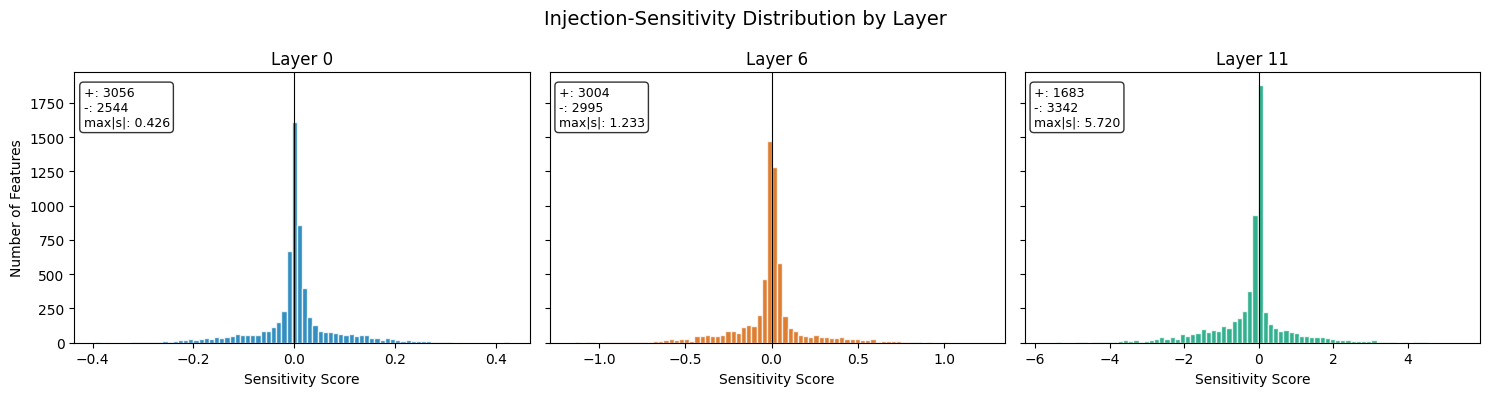

Saved to /content/drive/MyDrive/iris/results/figures/a1_sensitivity_by_layer.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
colors = ['#0072B2', '#D55E00', '#009E73']

for ax, layer, color in zip(axes, TARGET_LAYERS, colors):
    sens = layer_sensitivity[layer]
    ax.hist(sens, bins=80, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax.set_xlabel('Sensitivity Score')
    ax.set_title(f'Layer {layer}')

    # Stats
    n_pos = (sens > 0).sum()
    n_neg = (sens < 0).sum()
    max_abs = np.abs(sens).max()
    ax.text(0.02, 0.95, f'+: {n_pos}\n-: {n_neg}\nmax|s|: {max_abs:.3f}',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

axes[0].set_ylabel('Number of Features')
fig.suptitle('Injection-Sensitivity Distribution by Layer', fontsize=14)
plt.tight_layout()

save_path = DRIVE_ROOT / 'results' / 'figures' / 'a1_sensitivity_by_layer.png'
save_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(str(save_path), dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved to {save_path}')

## Step 5: Layer Comparison Bar Chart

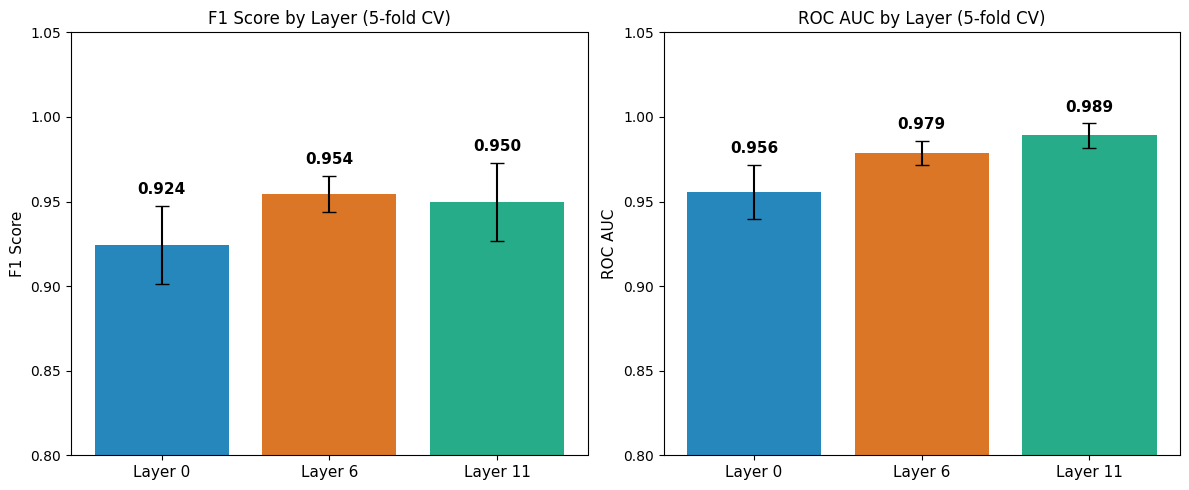

Saved to /content/drive/MyDrive/iris/results/figures/a1_layer_comparison.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#0072B2', '#D55E00', '#009E73']
layer_labels = [f'Layer {l}' for l in TARGET_LAYERS]
x = np.arange(len(TARGET_LAYERS))

for ax, metric, title in zip(axes, ['f1', 'auc'], ['F1 Score', 'ROC AUC']):
    means = [layer_cv_results[l][f'{metric}_mean'] for l in TARGET_LAYERS]
    stds = [layer_cv_results[l][f'{metric}_std'] for l in TARGET_LAYERS]

    bars = ax.bar(x, means, yerr=stds, capsize=5, color=colors, alpha=0.85)
    for bar, mean, std in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.005,
                f'{mean:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(layer_labels, fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'{title} by Layer (5-fold CV)', fontsize=12)
    ax.set_ylim(0.8, 1.05)

plt.tight_layout()
save_path = DRIVE_ROOT / 'results' / 'figures' / 'a1_layer_comparison.png'
fig.savefig(str(save_path), dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved to {save_path}')

In [9]:
# Save all A1 results
a1_results = {
    'experiment': 'A1',
    'layers': TARGET_LAYERS,
    'n_folds': N_FOLDS,
    'n_samples': len(labels),
    'sae_config': {
        'expansion_factor': EXPANSION_FACTOR,
        'sparsity_coeff': SPARSITY_COEFF,
        'epochs': EPOCHS,
    },
    'results': {str(k): v for k, v in layer_cv_results.items()},
    'training_metrics': {
        str(layer): trained_saes[layer]['final_metrics']
        for layer in TARGET_LAYERS
    },
}

results_path = DRIVE_ROOT / 'results' / 'metrics' / 'a1_multi_layer.json'
results_path.write_text(json.dumps(a1_results, indent=2))
print(f'Saved A1 results to {results_path}')

# Identify best layer
best_layer = max(TARGET_LAYERS, key=lambda l: layer_cv_results[l]['f1_mean'])
print(f'\nBest layer for detection: Layer {best_layer} '
      f'(F1={layer_cv_results[best_layer]["f1_mean"]:.3f})')
print('Use this layer for causal intervention experiments (C5).')

Saved A1 results to /content/drive/MyDrive/iris/results/metrics/a1_multi_layer.json

Best layer for detection: Layer 6 (F1=0.954)
Use this layer for causal intervention experiments (C5).
